# Cross-Validation and Preprocessing Pipelines

## Cross-Validation

### Implementing $k$-Fold Cross-Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

housing = fetch_california_housing(as_frame=True)
X_housing = housing.data
y_housing = housing.target

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_housing, y_housing, test_size=0.40, random_state=RANDOM_SEED
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_SEED
)

# ── 10-fold CV on California Housing with Ridge regression ────────────────
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0))
])

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

cv_r2   = cross_val_score(pipe_ridge, X_tr, y_tr, cv=kf,
                          scoring="r2")
cv_rmse = cross_val_score(pipe_ridge, X_tr, y_tr, cv=kf,
                          scoring="neg_root_mean_squared_error")

print("10-fold CV — Ridge Regression on California Housing (training set)")
print(f"  R²   : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}  (per-fold range: "
      f"[{cv_r2.min():.4f}, {cv_r2.max():.4f}])")
print(f"  RMSE : {(-cv_rmse).mean():.4f}  ±  {(-cv_rmse).std():.4f}  (per-fold range: "
      f"[{(-cv_rmse).min():.4f}, {(-cv_rmse).max():.4f}])")

10-fold CV — Ridge Regression on California Housing (training set)
  R²   : 0.6105  ±  0.0218  (per-fold range: [0.5893, 0.6557])
  RMSE : 0.7181  ±  0.0169  (per-fold range: [0.6872, 0.7414])


### Choosing $k$: The Bias-Variance Tradeoff for CV Itself

In [2]:
# ── CV error stability: comparing k=3, 5, 10, 20 ─────────────────────────
k_values = [3, 5, 10, 20]
results = []

for k in k_values:
    kf_k = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(pipe_ridge, X_tr, y_tr, cv=kf_k, scoring="r2")
    results.append({
        "k": k, "mean": scores.mean(),
        "std": scores.std(), "scores": scores
    })

print(f"{'k':>4}  {'Mean R²':>10}  {'Std R²':>10}")
print("-" * 30)
for r in results:
    print(f"{r['k']:>4}  {r['mean']:>10.4f}  {r['std']:>10.4f}")

   k     Mean R²      Std R²
------------------------------
   3      0.6096      0.0124
   5      0.6106      0.0187
  10      0.6105      0.0218
  20      0.6098      0.0286


## Feature Preprocessing and Pipelines

### Building a Preprocessing Pipeline

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ── Full preprocessing + model pipeline ───────────────────────────────────
numeric_features = list(X_housing.columns)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # handle missing values
    ("scaler",  StandardScaler())                    # zero mean, unit variance
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])

pipe_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        Ridge(alpha=1.0))
])

# ── Fit on training set, evaluate on validation set ───────────────────────
pipe_full.fit(X_tr, y_tr)
y_pred_val = pipe_full.predict(X_val)
y_pred_te  = pipe_full.predict(X_te)

val_r2   = r2_score(y_val, y_pred_val)
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
te_r2    = r2_score(y_te, y_pred_te)
te_rmse  = np.sqrt(mean_squared_error(y_te, y_pred_te))

print("Pipeline: Imputation → StandardScaler → Ridge(α=1)")
print(f"\n  Validation  R² = {val_r2:.4f}   RMSE = {val_rmse:.4f}")
print(f"  Test        R² = {te_r2:.4f}   RMSE = {te_rmse:.4f}")

Pipeline: Imputation → StandardScaler → Ridge(α=1)

  Validation  R² = 0.5920   RMSE = 0.7298
  Test        R² = 0.5955   RMSE = 0.7447


### Comparing Preprocessing Strategies

In [4]:
# ── Compare three scalers ──────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scalers = {
    "StandardScaler":   StandardScaler(),
    "MinMaxScaler":     MinMaxScaler(),
    "RobustScaler":     RobustScaler()
}

print(f"{'Scaler':20s}  {'Val R²':>8}  {'Val RMSE':>10}  {'10-CV R²':>10}")
print("-" * 56)

kf10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

for name, scaler in scalers.items():
    pipe_s = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  scaler),
        ("ridge",   Ridge(alpha=1.0))
    ])
    pipe_s.fit(X_tr, y_tr)
    y_v = pipe_s.predict(X_val)
    v_r2   = r2_score(y_val, y_v)
    v_rmse = np.sqrt(mean_squared_error(y_val, y_v))
    cv_r2s = cross_val_score(pipe_s, X_tr, y_tr, cv=kf10, scoring="r2")
    print(f"{name:20s}  {v_r2:8.4f}  {v_rmse:10.4f}  {cv_r2s.mean():10.4f}")

Scaler                  Val R²    Val RMSE    10-CV R²
--------------------------------------------------------
StandardScaler          0.5920      0.7298      0.6105
MinMaxScaler            0.5871      0.7341      0.6032
RobustScaler            0.5920      0.7298      0.6105


### Visualising Residuals

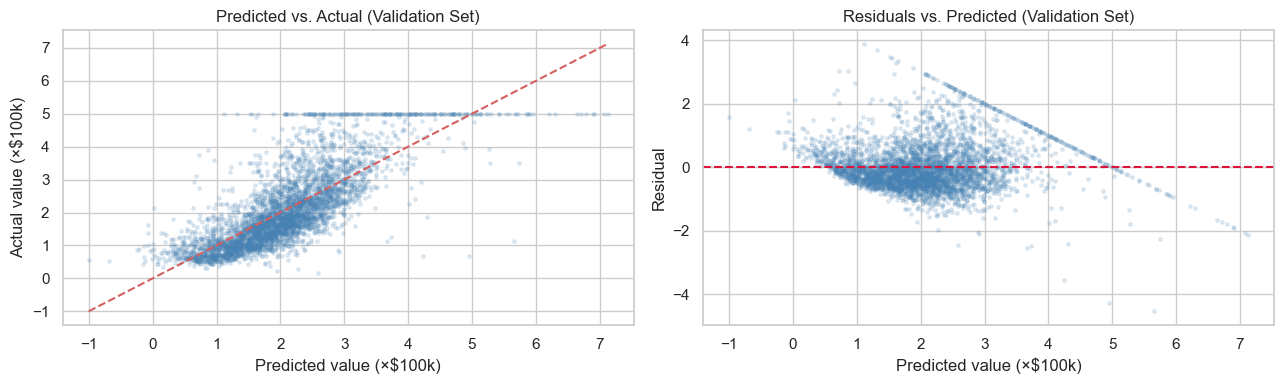

Residual mean : +0.0038  (should be ≈ 0)
Residual std  :  0.7298


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resid_val = y_val.values - y_pred_val

# Panel 1: predicted vs. actual
axes[0].scatter(y_pred_val, y_val, alpha=0.15, s=6, color="steelblue")
lims = [min(y_pred_val.min(), y_val.min()),
        max(y_pred_val.max(), y_val.max())]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_title("Predicted vs. Actual (Validation Set)")
axes[0].set_xlabel("Predicted value (×$100k)")
axes[0].set_ylabel("Actual value (×$100k)")

# Panel 2: residuals vs. predicted
axes[1].scatter(y_pred_val, resid_val, alpha=0.15, s=6, color="steelblue")
axes[1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1].set_title("Residuals vs. Predicted (Validation Set)")
axes[1].set_xlabel("Predicted value (×$100k)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.savefig(FIGURES / "ch10_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Residual mean : {resid_val.mean():+.4f}  (should be ≈ 0)")
print(f"Residual std  :  {resid_val.std():.4f}")